In [3]:

import random
import csv
import numpy as np
import matplotlib.pyplot as plt

Determino la estructura de mi red neuronal: el numero de cadas y neuronas para cada capa. En la variable estructura, el primer elemento son las entradas x1, x2,..., xn mientras que los proximos elementos son la cantidad de neuronas por capa

In [ ]:
estructura = np.array([2, 3, 1])
cant_capas = len(estructura) - 1
cant_salidas = estructura[-1]


In [5]:
trn = np.loadtxt('./data/XOR_trn.csv',delimiter=',')

inputs = np.empty(len(trn), dtype=object)
yd = np.empty(len(trn), dtype = object)

for i in range(len(trn)): 
  fila = trn[i]
  cant_entradas = estructura[0]
  yd[i] = fila[-1]

  aux = [-1] # Agrego el -1 correspondiente al sesgo
  for j in range(cant_entradas): 
    aux.append(fila[j])
  inputs[i] = aux


In [6]:
print(inputs)

[list([-1, np.float64(-1.0291), np.float64(0.97256)])
 list([-1, np.float64(1.0325), np.float64(-1.0188)])
 list([-1, np.float64(1.0261), np.float64(1.0343)]) ...
 list([-1, np.float64(0.98116), np.float64(-0.99778)])
 list([-1, np.float64(-1.0046), np.float64(-0.99967)])
 list([-1, np.float64(-1.0), np.float64(0.98807)])]


In [ ]:
# Inicializamos la matriz de pesos para cada una de las capas
# Esto es una matriz de matrices 
# El elemento w_ij = w[i][j] de la matriz me da los pesos correspondientes a la neurona j de la capa i. 


w = []

for i in range(len(estructura)-1): 
  n_neuronas = estructura[i+1]
  n_entradas = estructura[i] + 1
  w_aux = np.random.rand( n_neuronas, n_entradas)-0.5
  w.append(w_aux)

# Almacenamos los vectores de salida de cada capa
y = np.empty(cant_capas, dtype=object)
delta = np.empty(cant_capas, dtype=object)

print(w)

[array([[ 0.40528048, -0.15300243,  0.14792441],
       [-0.31208877, -0.07687063, -0.38917439]]), array([[ 0.37100526,  0.4994732 , -0.10182719]])]


In [5]:
def sigmoidea(v):
    return ((2/(1+np.exp(-v)))-1)

def d_sigmoidea(y):
    return ((1+y)*(1-y))

In [ ]:
# DATOS PARA EL ALGORITMO:
epocas = 20      # Máximo de iteraciones
mu = 0.01               # Velocidad de aprendizaje
perc_error_max = 0.01   # Porcentaje máximo de error
errores_por_epoca = []
mse_por_epoca = []


for epoca in range(epocas):     
  for patron in range(len(inputs)): 
    entradas = inputs[patron]
    y_deseada = yd[patron]
    # PROPAGACION HACIA ADELANTE
    for capa in range(cant_capas):
     
      v = np.dot(w[capa], entradas)
      y[capa] = sigmoidea(v)
      entradas = np.hstack((-1,y[capa])) 

    # PROPAGACION HACIA ATRAS
    e = y_deseada - y[-1]
    delta[-1] = e*1/2*d_sigmoidea(y[-1])

    for i in range(cant_capas-1,0,-1):
      
      w_i = w[i][:, 1:].T
      d  = np.dot(w_i, delta[i])
      
      delta[i-1] = d*(1/2)*d_sigmoidea(y[i-1])

    
    entradas = inputs[patron] 
    print(f"deltas: {delta}")         # La primera capa tiene las entradas en el archivo .csv
    for capa in range(cant_capas): 
      delta_peso = mu*(np.outer(delta[capa],entradas))
      
      w[capa] += delta_peso
      
      entradas = np.hstack((-1,y[capa]))    # Entrada para próxima capa es la salida de esta

  cont_errores = 0
  cont_mse = 0

  for patron in range(len(trn)): 
    entradas = inputs[patron]

    for capa in range(cant_capas): 
      v = np.dot(w[capa], entradas)
      y[capa] = sigmoidea(v)
      entradas = np.hstack((-1,y[capa]))    # Entrada de la próxima capa es la salida de esta capa

    # CODIFICACIÓN: Función signo
    yc = np.sign(y[-1])

    # Actualizo contadores de error:
    if((yd[patron] != yc).any()): cont_errores += 1
    cont_mse += np.sum(np.square(yd[patron]-y[-1]))

  mse = cont_mse / len(trn) # Promedio de los errores obtenidos en esta epoca
  mse_por_epoca.append(mse)

  perc_error = cont_errores/len(trn)
  errores_por_epoca.append(perc_error)

  if perc_error < perc_error_max: 
    break

acierto = (1-cont_errores/len(trn))*100
print('Finalizó el entrenamiento en la época ',epoca,' con ',cont_errores,'/',len(trn),' errores. Tasa de acierto: ',round(acierto,2),'%')

delta de pesos [[-0.00143231 -0.00147399  0.00139301]
 [ 0.00029278  0.0003013  -0.00028475]]
w: [[ 0.40528048 -0.15300243  0.14792441]
 [-0.31208877 -0.07687063 -0.38917439]]
delta de pesos [[-5.75080801e-03 -2.98658953e-04  3.65197130e-05]]
w: [[ 0.37100526  0.4994732  -0.10182719]]
delta de pesos [[-0.00129788  0.00134006 -0.00132228]
 [ 0.00027214 -0.00028098  0.00027725]]
w: [[ 0.40384817 -0.15447643  0.14931743]
 [-0.31179599 -0.07656933 -0.38945914]]
delta de pesos [[-0.00589446 -0.00202308  0.0017964 ]]
w: [[ 0.36525445  0.49917454 -0.10179067]]
delta de pesos [[ 0.00088301 -0.00090606 -0.0009133 ]
 [-0.00018372  0.00018851  0.00019002]]
w: [[ 0.40255029 -0.15313637  0.14799515]
 [-0.31152385 -0.07685031 -0.38918188]]
delta de pesos [[0.00370114 0.00074227 0.00031359]]
w: [[ 0.35936     0.49715147 -0.09999427]]
delta de pesos [[ 0.00087841 -0.000866   -0.00085349]
 [-0.00018253  0.00017995  0.00017735]]
w: [[ 0.4034333  -0.15404242  0.14708185]
 [-0.31170757 -0.07666179 -0.3889

In [82]:

tst = np.loadtxt('./data/XOR_tst.csv',delimiter=',')
inputs = np.empty(len(tst),dtype=object)      # Vector de entradas
yd = np.empty(len(tst),dtype=object)          # Salida esperadas
for i in range(len(tst)):
  fila = tst[i]
  cant_e = estructura[0]   # Cantidad de entradas
  yd[i] = fila[cant_e:]     
  aux = [-1]                  # Añado entrada -1 correspondiente al umbral/sesgo
  for j in range(cant_e):
    aux.append(fila[j])
    inputs[i] = aux                # Vector de entradas por patrón

In [83]:

y = np.empty(cant_capas,dtype=object)   # Vector de salidas
cont_errores = 0                        # Contador de errores
x_saved = [] # Guardo las salidas por epoca de la capa de entrada para graficar la capa de salida
y_saved = [] # Guardo la salida por epoca de la capa de salida para determinar el color del punto

for patron in range(len(tst)): 
    entradas = inputs[patron]
    for i in range(cant_capas):
        v = w[i]@entradas                   # Producto interno de pesos y entradas
        y[i] = sigmoidea(v)               # Salida con función de activación
        entradas = np.hstack((-1,y[i]))     # La entrada de la próxima capa es la salida de la actual.

    yc = np.sign(y[-1])
    if((yd[patron] != yc).any()): cont_errores += 1

    x_saved.append(np.sign(y[0]))
    y_saved.append(yc)

acierto = (1-cont_errores/len(tst))*100
print('Finalizó la prueba con ',cont_errores,'/',len(tst),' errores. Tasa de acierto: ',round(acierto,2),'%')

Finalizó la prueba con  0 / 200  errores. Tasa de acierto:  100.0 %


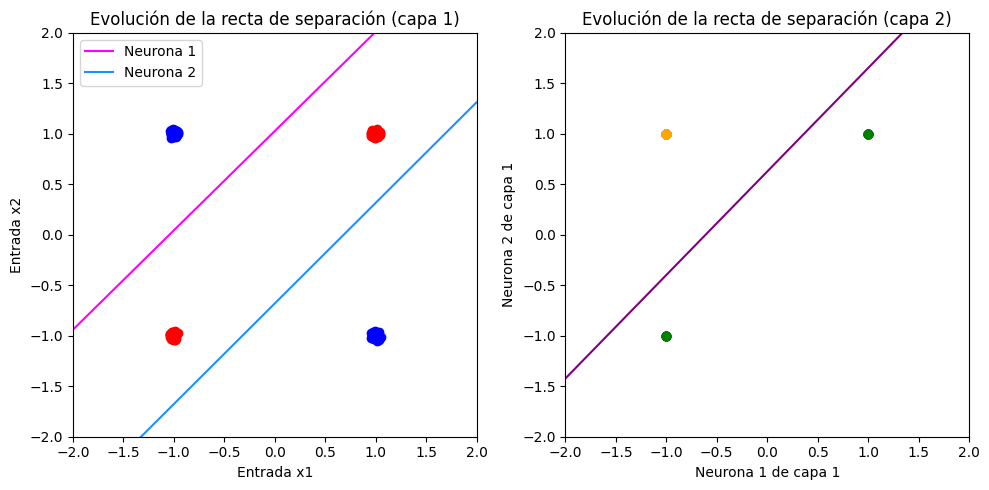

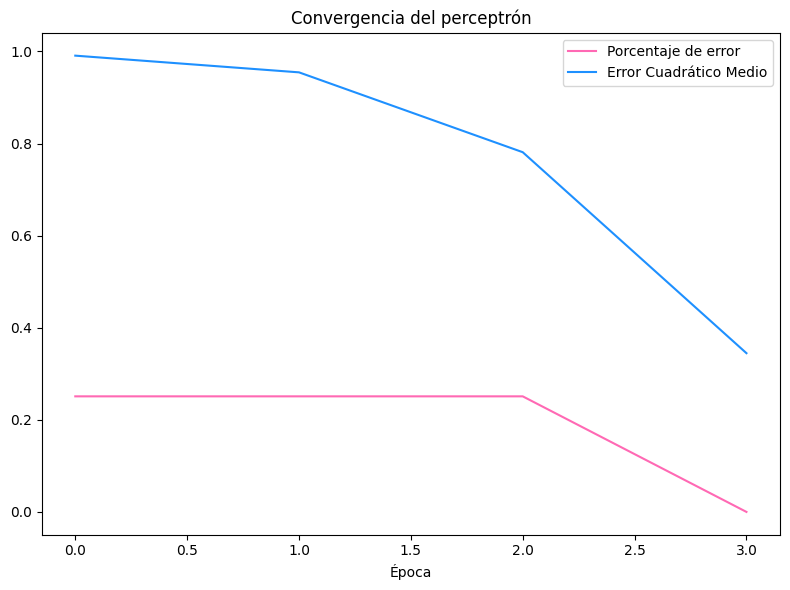

In [84]:
fig,ax = plt.subplots(1,2,figsize=(10,5))

# GRÁFICAS DE RECTA DE SEPARACIÓN
ax[0].set(xlim=[-2,2],ylim=[-2,2],xlabel='Entrada x1',ylabel='Entrada x2',title='Evolución de la recta de separación (capa 1)')
ax[1].set(xlim=[-2,2],ylim=[-2,2],xlabel='Neurona 1 de capa 1',ylabel='Neurona 2 de capa 1',title='Evolución de la recta de separación (capa 2)')
xx = np.linspace(-2, 2, 100)

# ------------- CAPA 1 ------------- #
# PUNTOS:
for i in range(len(yd)):
    if yd[i] == -1: # Según resultado esperado de la entrada:
        ax[0].scatter(tst[i,0], tst[i,1], color='red') 
    else:
        ax[0].scatter(tst[i,0], tst[i,1], color='blue') 

# RECTA:
w11 = w[0][0]
w12 = w[0][1]
y11 = w11[0]/w11[2] - (w11[1]/w11[2])*xx
y12 = w12[0]/w12[2] - (w12[1]/w12[2])*xx

ax[0].plot(xx,y11,label='Neurona 1',color='fuchsia')
ax[0].plot(xx,y12,label='Neurona 2',color='dodgerblue')
ax[0].legend()

# ------------- CAPA 2 ------------- #
# PUNTOS:
for i in range(len(y_saved)):
    x1 = x_saved[i][0]
    x2 = x_saved[i][1]
    if (y_saved[i] == 1): # Según resultado esperado de la entrada:
        ax[1].scatter(x1,x2, color='green') 
    else: ax[1].scatter(x1,x2, color='orange') 

# RECTA:
w21 = w[1][0]
y21 = w21[0]/w21[2] - (w21[1]/w21[2])*xx

ax[1].plot(xx,y21,'purple')
plt.tight_layout()
plt.show()

# GRÁFICAS DE ERROR
fig,ax = plt.subplots(figsize=(8,6))
ax.set(title='Convergencia del perceptrón')
x = range(len(errores_por_epoca))

ax.plot(x, errores_por_epoca, label='Porcentaje de error',color='hotpink')
ax.plot(x, mse_por_epoca, label='Error Cuadrático Medio',color='dodgerblue')
ax.set_xlabel('Época')
ax.legend()
plt.tight_layout()
plt.show()